Reto modulo 3 - Itzel Pamela Hernández Ramírez

Creación de modelo para saber si un cliente contratará un deposito a plazo fijo. De acuerdo a los datos obtenidos de campañas de marketing.

In [205]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

In [206]:
data = pd.read_csv("bank_marketing_RETO_DS_AS.csv")
data.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,31,self-employed,married,tertiary,no,2666,no,no,cellular,10,nov,318,2,97,6,success,yes
1,29,unemployed,single,unknown,no,1584,no,no,cellular,6,sep,245,1,-1,0,unknown,yes
2,41,blue-collar,married,secondary,no,2152,yes,no,cellular,17,nov,369,1,-1,0,unknown,no
3,50,blue-collar,married,secondary,no,84,yes,no,cellular,17,jul,18,8,-1,0,unknown,no
4,40,admin.,married,secondary,no,0,no,no,cellular,28,jul,496,2,182,11,success,yes


In [207]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   object
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   object
 7   loan       9000 non-null   object
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   object
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   object
dtypes: int64(7), object(10)
memory usage: 1.2+ MB


Transformar las variables categóricas a númericas

In [208]:
encoder = OneHotEncoder(sparse_output=False) 

# Ajustar y transformar
encoded = encoder.fit_transform(data[['job']])

# Crear DataFrame con nombres de columnas 
job_OH = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['job']))
job_OH.head(2)


,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [209]:
# Ajustar y transformar
encoded = encoder.fit_transform(data[['marital']])

# Crear DataFrame con nombres de columnas 
marital_OH = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['marital']))
marital_OH.head(2)

,marital_divorced,marital_married,marital_single
0,0.0,1.0,0.0
1,0.0,0.0,1.0


In [210]:
# Ajustar y transformar
encoded = encoder.fit_transform(data[['education']])

# Crear DataFrame con nombres de columnas 
education_OH = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['education']))
education_OH.head(2)

,education_primary,education_secondary,education_tertiary,education_unknown
0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0


In [211]:
# Ajustar y transformar
encoded = encoder.fit_transform(data[['contact']])

# Crear DataFrame con nombres de columnas 
contact_OH = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['contact']))
contact_OH.head(2)

,contact_cellular,contact_telephone,contact_unknown
0,1.0,0.0,0.0
1,1.0,0.0,0.0


In [212]:
encoded = encoder.fit_transform(data[['poutcome']])

# Crear DataFrame con nombres de columnas 
poutcome_OH = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['poutcome']))
poutcome_OH.head(2)

,poutcome_failure,poutcome_other,poutcome_success,poutcome_unknown
0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0


In [213]:
#Puedo usar en label enconder para las que solo son 2 variables 0 para NO y 1 para SI

from sklearn.preprocessing import LabelEncoder

# Instanciar y transformar
label_encoder = LabelEncoder()
data['default'] = label_encoder.fit_transform(data['default'])
data['housing'] = label_encoder.fit_transform(data['housing'])
data['loan'] = label_encoder.fit_transform(data['loan'])
data['y'] = label_encoder.fit_transform(data['y'])


In [214]:
#Para el caso de los meses se busco la opción de nosotros asignar el valor que le squeremos dar y que quede en una solo columna.
meses_map = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

data['month'] = data['month'].map(meses_map)


In [215]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        9000 non-null   int64 
 1   job        9000 non-null   object
 2   marital    9000 non-null   object
 3   education  9000 non-null   object
 4   default    9000 non-null   int32 
 5   balance    9000 non-null   int64 
 6   housing    9000 non-null   int32 
 7   loan       9000 non-null   int32 
 8   contact    9000 non-null   object
 9   day        9000 non-null   int64 
 10  month      9000 non-null   int64 
 11  duration   9000 non-null   int64 
 12  campaign   9000 non-null   int64 
 13  pdays      9000 non-null   int64 
 14  previous   9000 non-null   int64 
 15  poutcome   9000 non-null   object
 16  y          9000 non-null   int32 
dtypes: int32(4), int64(8), object(5)
memory usage: 1.0+ MB


Borramos las columnas que ya no vamos a usar y concatenamos los df creados por el one hot encoder

In [216]:
#Borrar columnas categóricas
df = data.drop(['job','marital','education','contact','poutcome'], axis=1)

In [217]:
#Concateno los df de las variables numericas HO
data_final = pd.concat([df,job_OH,marital_OH,education_OH,contact_OH,poutcome_OH], axis=1)

In [218]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 38 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  9000 non-null   int64  
 1   default              9000 non-null   int32  
 2   balance              9000 non-null   int64  
 3   housing              9000 non-null   int32  
 4   loan                 9000 non-null   int32  
 5   day                  9000 non-null   int64  
 6   month                9000 non-null   int64  
 7   duration             9000 non-null   int64  
 8   campaign             9000 non-null   int64  
 9   pdays                9000 non-null   int64  
 10  previous             9000 non-null   int64  
 11  y                    9000 non-null   int32  
 12  job_admin.           9000 non-null   float64
 13  job_blue-collar      9000 non-null   float64
 14  job_entrepreneur     9000 non-null   float64
 15  job_housemaid        9000 non-null   f

Ver variables con posible sesgo

In [219]:
import matplotlib.pyplot as plt

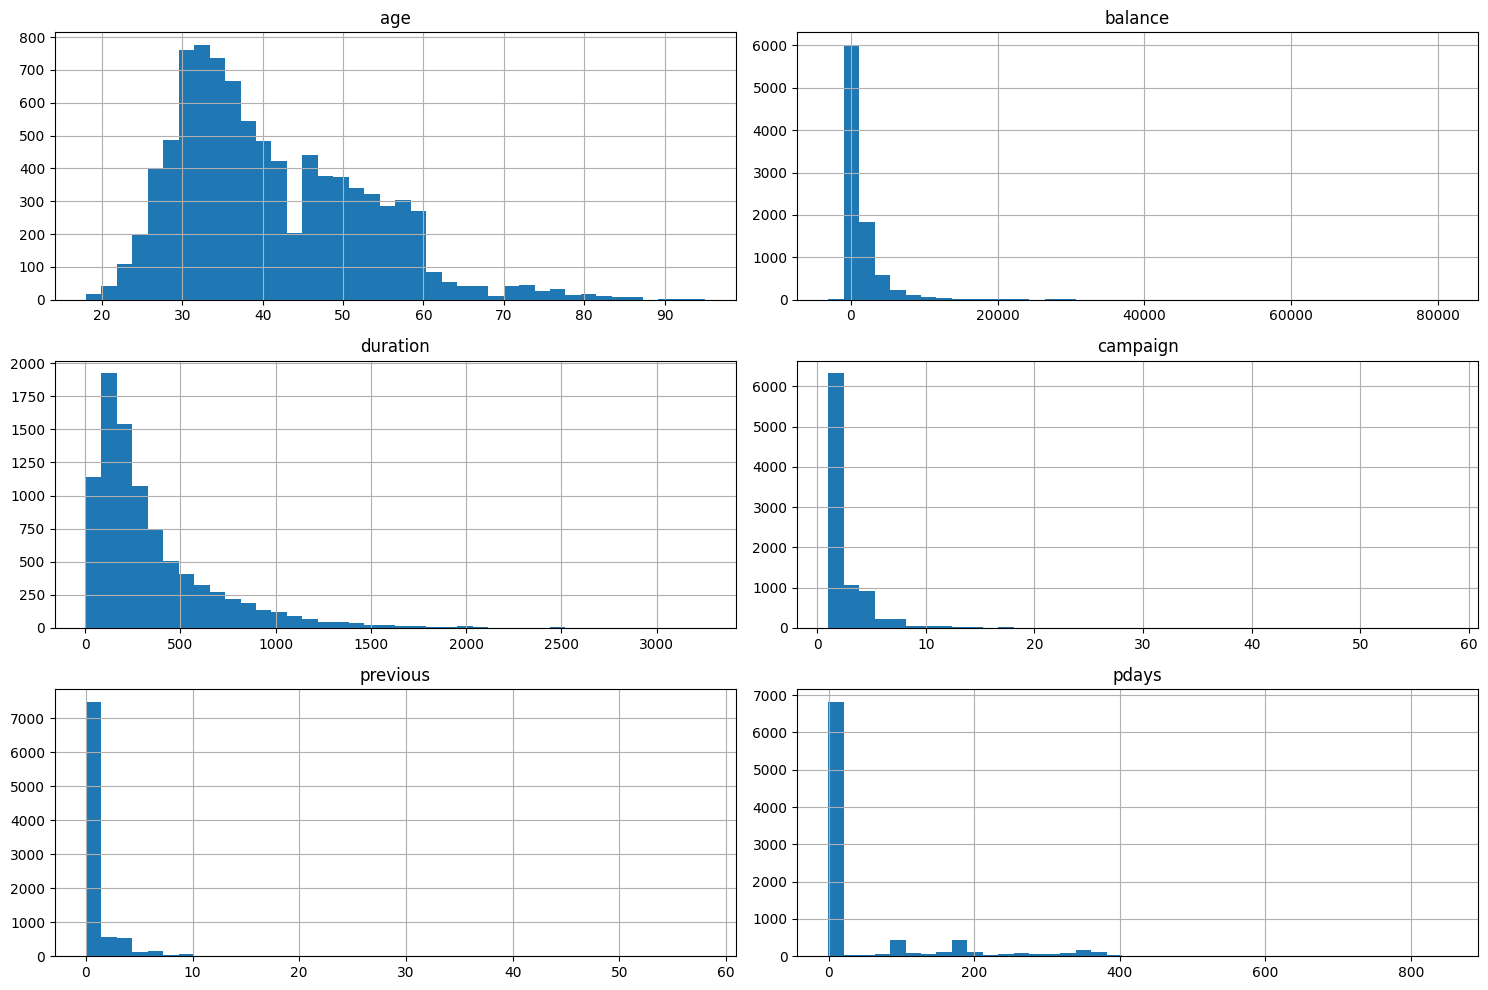

In [220]:
# Genera histogramas para variables numericas y ver su sesgo
df_histo = data_final[['age','balance','duration','campaign','previous','pdays']]
df_histo.hist(bins=40, figsize=(15, 10))

# Ajusta el diseño para que no se encimen las etiquetas
plt.tight_layout()
plt.show()

In [221]:
#Transformación logaritmica por sesgo positivo
def fun1(X):
    return np.log(X + 1)

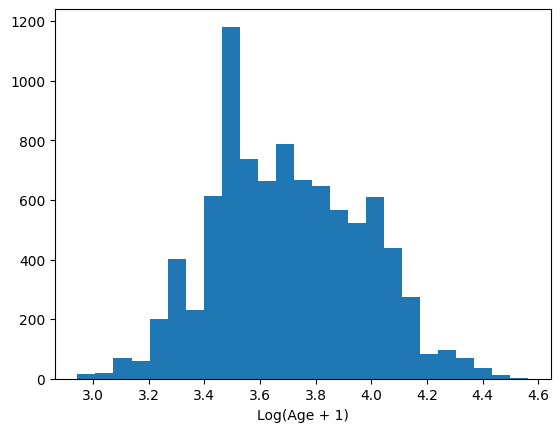

In [222]:
age = np.array(data_final["age"])

plt.hist(fun1(age), bins=25)
plt.xlabel("Log(Age + 1)")
plt.show()

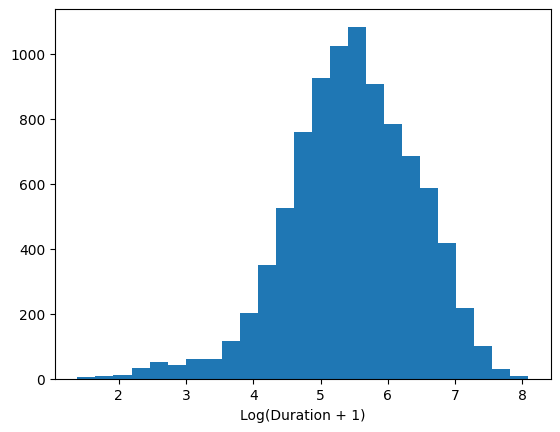

In [223]:
duration = np.array(data_final["duration"])

plt.hist(fun1(duration), bins=25)
plt.xlabel("Log(Duration + 1)")
plt.show()

In [224]:
#ESTANDARIZACIÓN esta transformación a la variable balance porque tiene valores negativos y no aplica la funcion logaritmica
def fun2(X):
    return (X - np.mean(X)) / np.std(X)

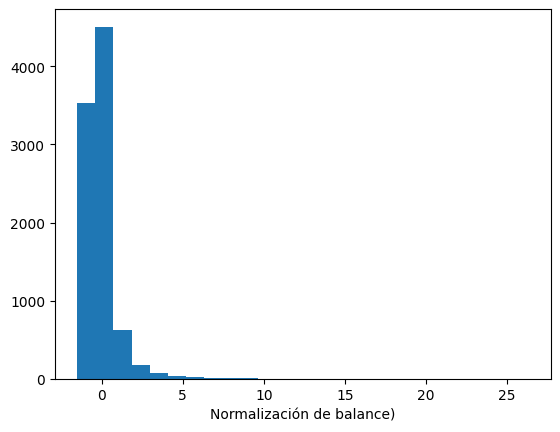

In [225]:

balance = np.array(data_final["balance"])

plt.hist(fun2(balance), bins=25)
plt.xlabel("Normalización de balance)")
plt.show()

Definir variables de entrada y salida. Y particion de Datos

In [226]:
data_final.columns

Index(['age', 'default', 'balance', 'housing', 'loan', 'day', 'month',
       'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'poutcome_failure', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown'],
      dtype='object')

In [227]:
#definimos variables entrada X y de salida Y
X= data_final[['age', 'default', 'balance', 'housing', 'loan', 'day', 'month',
       'duration', 'campaign', 'pdays', 'previous', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'education_primary', 'education_secondary', 'education_tertiary',
       'education_unknown', 'contact_cellular', 'contact_telephone',
       'contact_unknown', 'poutcome_failure', 'poutcome_other',
       'poutcome_success', 'poutcome_unknown']]

Y= data_final['y']

X = X.values
Y = Y.values

In [228]:
#definimos la particion de los datos de entranamiento, validacion y pruba 60%, 20% y 20%
#Extracción de información
from sklearn.model_selection import train_test_split

x_train, x_validation_and_test, y_train, y_validation_and_test = train_test_split(X, Y, train_size=0.60)
x_validation, x_test, y_validation, y_test = train_test_split(x_validation_and_test, y_validation_and_test, test_size=0.50)

Aplicamos Modelo de Regresión Logistica

In [229]:
#Aplicaremos el modelo de regresion logistica, que es para problemas de clasificación binaria (0 y1)
from sklearn.linear_model import LogisticRegression
clf_base = LogisticRegression( C=1, solver='newton-cg')  #solver podemos cambiar el metodo solucionador ver libreria scikit
modelo_RL = clf_base.fit( x_train, y_train ) #estoy usando tambien datos de salida por eso supervisado

In [230]:
#ontener la exactitud (accuracy) del modelo
print("Exactitud (accuracy) con el conjunto de Validación = ", modelo_RL.score(x_validation, y_validation))

Exactitud (accuracy) con el conjunto de Validación =  0.8172222222222222


In [231]:
#matriz de confusión para detalle de la manera en que realiza las predicciones correctas y erroneas
from sklearn.metrics import confusion_matrix
pr = modelo_RL.predict(x_validation)
confusion_matrix(y_validation, pr)

array([[929, 117],
       [212, 542]], dtype=int64)

En este modelo tengo una exactitud del ~82%.
La matriz de confusión me dice que dio 929 verdaderos negativos de que los clientes no comprarán un deposito a plazo fijo.
y 542 verdaderos positivos de que si comprarán el deposito.

AJUSTAMOS PARAMETROS PARA OBTENER EL MEJOR MODEO DE REGRESION LINEAL

In [241]:
clf_1 = LogisticRegression( C=3, solver='newton-cg') 
modelo_RL1 = clf_1.fit( x_train, y_train ) 

clf_2 = LogisticRegression( C=0.22, solver='newton-cg') 
modelo_RL2 = clf_2.fit( x_train, y_train ) 

clf_3 = LogisticRegression( C=0.3, solver='newton-cg') 
modelo_RL3 = clf_3.fit( x_train, y_train ) 

clf_4 = LogisticRegression( C=0.1, solver='newton-cg') 
modelo_RL4 = clf_4.fit( x_train, y_train ) 

clf_5 = LogisticRegression( C=0.22, solver='lbfgs') 
modelo_RL5 = clf_5.fit( x_train, y_train ) 

clf_6 = LogisticRegression( C=0.22, solver='saga') 
modelo_RL6 = clf_6.fit( x_train, y_train ) 

c:\Users\iphernandez\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\iphernandez\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [242]:
print("Exactitud (accuracy) con el conjunto de Validación clf_1 = ", modelo_RL1.score(x_validation, y_validation))
print("Exactitud (accuracy) con el conjunto de Validación clf_2 = ", modelo_RL2.score(x_validation, y_validation))
print("Exactitud (accuracy) con el conjunto de Validación clf_3 = ", modelo_RL3.score(x_validation, y_validation))
print("Exactitud (accuracy) con el conjunto de Validación clf_4 = ", modelo_RL4.score(x_validation, y_validation))
print("Exactitud (accuracy) con el conjunto de Validación clf_5 = ", modelo_RL5.score(x_validation, y_validation))
print("Exactitud (accuracy) con el conjunto de Validación clf_6 = ", modelo_RL6.score(x_validation, y_validation))

Exactitud (accuracy) con el conjunto de Validación clf_1 =  0.8183333333333334
Exactitud (accuracy) con el conjunto de Validación clf_2 =  0.8183333333333334
Exactitud (accuracy) con el conjunto de Validación clf_3 =  0.8188888888888889
Exactitud (accuracy) con el conjunto de Validación clf_4 =  0.8194444444444444
Exactitud (accuracy) con el conjunto de Validación clf_5 =  0.7755555555555556
Exactitud (accuracy) con el conjunto de Validación clf_6 =  0.5022222222222222


In [243]:
#Matriz de confusión
pr1 = modelo_RL1.predict(x_validation)
confusion_matrix(y_validation, pr1)

array([[930, 116],
       [211, 543]], dtype=int64)

In [244]:
#Matriz de confusión
pr2 = modelo_RL2.predict(x_validation)
confusion_matrix(y_validation, pr2)

array([[928, 118],
       [209, 545]], dtype=int64)

In [245]:
#Matriz de confusión
pr3 = modelo_RL3.predict(x_validation)
confusion_matrix(y_validation, pr3)

array([[929, 117],
       [209, 545]], dtype=int64)

In [246]:
#Matriz de confusión
pr4 = modelo_RL4.predict(x_validation)
confusion_matrix(y_validation, pr4)

array([[928, 118],
       [207, 547]], dtype=int64)

In [247]:
#Matriz de confusión
pr5 = modelo_RL5.predict(x_validation)
confusion_matrix(y_validation, pr5)

array([[894, 152],
       [252, 502]], dtype=int64)

In [248]:
#Matriz de confusión
pr6 = modelo_RL6.predict(x_validation)
confusion_matrix(y_validation, pr6)

array([[185, 861],
       [ 35, 719]], dtype=int64)

Modelo Red Neuronal

In [249]:
from sklearn.neural_network import MLPClassifier

In [250]:
#red neuronal con 15 y 4 neuronas en la primera y segunda capas ocultas, respectivamente. 

modelo_NN = MLPClassifier(hidden_layer_sizes=(15,4), max_iter=700)

In [251]:
modelo_NN.fit(x_train, y_train)
print(modelo_NN.score(x_validation, y_validation))

0.77


In [252]:
modelo_NN1 = MLPClassifier(hidden_layer_sizes=(20,9), max_iter=700)
modelo_NN1.fit(x_train, y_train)
print(modelo_NN1.score(x_validation, y_validation))

0.715


In [253]:
modelo_NN2 = MLPClassifier(hidden_layer_sizes=(20,9), max_iter=900)
modelo_NN2.fit(x_train, y_train)
print(modelo_NN2.score(x_validation, y_validation))

0.7994444444444444


In [256]:
modelo_NN3 = MLPClassifier(hidden_layer_sizes=(20,9), max_iter=1000, random_state=50)
modelo_NN3.fit(x_train, y_train)
print(modelo_NN3.score(x_validation, y_validation))

0.7844444444444445


In [255]:
modelo_NN4 = MLPClassifier(hidden_layer_sizes=(30,19), max_iter=700)
modelo_NN4.fit(x_train, y_train)
print(modelo_NN4.score(x_validation, y_validation))

0.7916666666666666


MEJOR MODELO ENCONTRADO

El mejor modelo encontrado corresponde a clf_4:
clf_4 = LogisticRegression( C=0.1, solver='newton-cg')

modelo_RL4 = clf_4.fit( x_train, y_train ) 

In [257]:
print("Exactitud (accuracy) con el conjunto de Validación clf_4 = ", modelo_RL4.score(x_test, y_test))

Exactitud (accuracy) con el conjunto de Validación clf_4 =  0.8022222222222222


In [258]:
#Matriz de confusión
pr4 = modelo_RL4.predict(x_test)
confusion_matrix(y_test, pr4)

array([[911, 130],
       [226, 533]], dtype=int64)

El mejor modelo fue utilizando la regresión logística, en el cual se obtuvo una exactitud del 80%. Utilizando newton-cg como método de regresión.
Este modelo nos da una precisión del 80.39% para detectar las personas que realmente van a comprar depósito bancario a largo plazo.

Con apoyo de determincación de modelos para predecir ya se si alguien va adquir un crédito o algun producto, es de gran ayuda en mercadotecnia, ya que, la empresa se puede concentrar en cierto numero de personas que si van a consumir sus productos o enfocarse en estrategias para mantener al grupo contrario.